# Equity MF (AUM) vs Market Returns Analysis
### Nifty 50 & Nifty 200 | Jan 2020 – May 2026
---
**Analyses covered**
1. Data loading & feature engineering (MoM flows, returns)
2. Descriptive statistics
3. Time-series plots (AUM, prices, MoM returns)
4. Correlation analysis + heatmaps
5. Rolling correlations
6. Lag correlation analysis (cross-correlation)
7. Granger causality tests (bidirectional)
8. OLS regression (contemporaneous & lagged)
9. Scatter plots with regression lines


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, ccf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# ── Dark theme ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#e6edf3',
    'text.color':        '#e6edf3',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'legend.labelcolor': '#e6edf3',
    'figure.titlesize':  14,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'font.family':       'DejaVu Sans',
})

ACCENT  = ['#58a6ff', '#f0883e', '#3fb950', '#d2a8ff', '#ffa657']
C_AUM   = '#58a6ff'   # blue
C_N50   = '#3fb950'   # green
C_N200  = '#f0883e'   # orange

print("Imports OK")


Imports OK


In [2]:
import pandas as pd
import numpy as np

# ============================================================
# Load Excel
# ============================================================

df = pd.read_excel("MF_and_market.xlsx", parse_dates=["Month"])

df = (
    df
    .sort_values("Month")
    .reset_index(drop=True)
)

# ============================================================
# Column names from Excel
# ============================================================

net_inflow_col = "Equity_Net_AUM_Cr"
mom_pct_col    = "MoM_Per_change"
nifty50_col    = "Nifty_50_Close_Price"
nifty200_col   = "NIFTY_200_Close"

# ============================================================
# Clean numeric columns
# ============================================================

num_cols = [
    net_inflow_col,
    mom_pct_col,
    nifty50_col,
    nifty200_col
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# Net inflow MoM percentage
# ============================================================
# Excel's MoM_Per_change is already the clean percentage-change logic.
# It appears stored as decimal form:
# 0.370479 means 37.0479%
# -0.404067 means -40.4067%

df["AUM_MoM_pct"] = df[mom_pct_col] * 100

# Safety fallback: if MoM_Per_change is missing for some row,
# calculate using always-positive denominator.
missing_mom = df["AUM_MoM_pct"].isna()

df.loc[missing_mom, "AUM_MoM_pct"] = (
    df[net_inflow_col].diff()
    / df[net_inflow_col].shift(1).abs()
) * 100

df["AUM_MoM_pct"] = df["AUM_MoM_pct"].replace(
    [np.inf, -np.inf],
    np.nan
)

# ============================================================
# Index returns
# ============================================================

df["Nifty50_ret"] = df[nifty50_col].pct_change() * 100
df["Nifty200_ret"] = df[nifty200_col].pct_change() * 100

# ============================================================
# Absolute net inflow change
# ============================================================

df["AUM_MoM_abs"] = df[net_inflow_col].diff()

# ============================================================
# Stationarity transformations
# ============================================================
# Do NOT use log_AUM because net inflow can be negative.
# Instead use inverse hyperbolic sine transformation.
# arcsinh works with positive, zero, and negative values.

df["asinh_AUM"] = np.arcsinh(df[net_inflow_col])
df["d_asinh_AUM"] = df["asinh_AUM"].diff()

# Logs only for market indices because index levels are always positive.

df["log_N50"] = np.log(df[nifty50_col])
df["log_N200"] = np.log(df[nifty200_col])

df["dlog_N50"] = df["log_N50"].diff()
df["dlog_N200"] = df["log_N200"].diff()

# ============================================================
# Clean dataframe for analysis
# ============================================================

analysis_cols = [
    "Month",
    net_inflow_col,
    "AUM_MoM_pct",
    "AUM_MoM_abs",
    "Nifty50_ret",
    "Nifty200_ret",
    "asinh_AUM",
    "d_asinh_AUM",
    "log_N50",
    "log_N200",
    "dlog_N50",
    "dlog_N200"
]

df_clean = df[analysis_cols].dropna().copy()

# ============================================================
# Output checks
# ============================================================

print(df.shape, "| Clean rows:", df_clean.shape[0])

print("\nAvailable columns:")
print(df.columns.tolist())

print("\nLast 5 rows:")
print(
    df.tail(5)[
        [
            "Month",
            net_inflow_col,
            "AUM_MoM_pct",
            "Nifty50_ret",
            "Nifty200_ret"
        ]
    ]
)

display(df_clean.tail())

(77, 15) | Clean rows: 76

Available columns:
['Month', 'Equity_Net_AUM_Cr', 'Nifty_50_Close_Price', 'NIFTY_200_Close', 'MoM_Per_change', 'AUM_MoM_pct', 'Nifty50_ret', 'Nifty200_ret', 'AUM_MoM_abs', 'asinh_AUM', 'd_asinh_AUM', 'log_N50', 'log_N200', 'dlog_N50', 'dlog_N200']

Last 5 rows:
        Month  Equity_Net_AUM_Cr  AUM_MoM_pct  Nifty50_ret  Nifty200_ret
72 2026-01-01           24028.59   -14.348975    -3.095914     -3.030585
73 2026-02-01           25977.91     8.112503    -0.560807      0.198679
74 2026-03-01           40450.26    55.710217   -11.308192    -11.535615
75 2026-04-01           38440.20    -4.969214     7.461019      9.713739
76 2026-05-01           22907.77   -40.406736    -1.874358     -0.305351


,Month,Equity_Net_AUM_Cr,AUM_MoM_pct,AUM_MoM_abs,Nifty50_ret,Nifty200_ret,asinh_AUM,d_asinh_AUM,log_N50,log_N200,dlog_N50,dlog_N200
72,2026-01-01,24028.59,-14.348975,-4025.47,-3.095914,-3.030585,10.780147,-0.154889,10.139376,9.553437,-0.031449,-0.030775
73,2026-02-01,25977.91,8.112503,1949.32,-0.560807,0.198679,10.858149,0.078002,10.133752,9.555422,-0.005624,0.001985
74,2026-03-01,40450.26,55.710217,14472.35,-11.308192,-11.535615,11.300976,0.442827,10.013749,9.432852,-0.120003,-0.122570
75,2026-04-01,38440.20,-4.969214,-2010.06,7.461019,9.713739,11.250006,-0.050969,10.085707,9.525556,0.071958,0.092704
76,2026-05-01,22907.77,-40.406736,-15532.43,-1.874358,-0.305351,10.732379,-0.517628,10.066786,9.522498,-0.018921,-0.003058


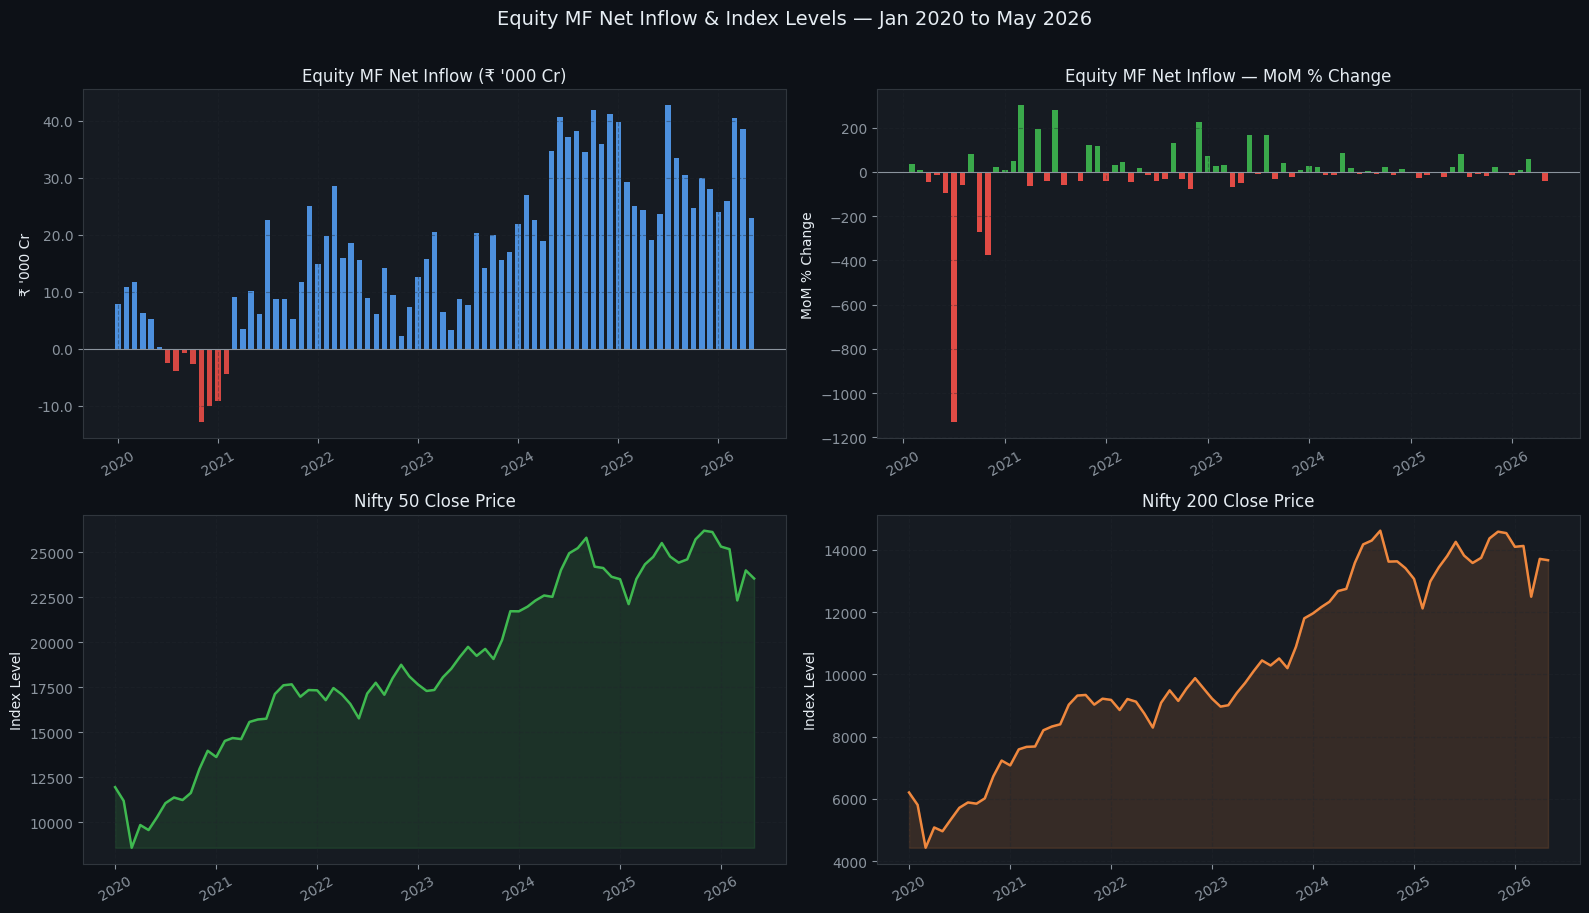

Fig 1 saved


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np

# ============================================================
# Figure 1 — Equity MF Net Inflow & Index Levels
# Jan 2020 to May 2026
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

fig.suptitle(
    "Equity MF Net Inflow & Index Levels — Jan 2020 to May 2026",
    fontsize=14,
    y=1.01
)

# ------------------------------------------------------------
# Graph 1 — Equity MF Net Inflow
# ------------------------------------------------------------

ax = axes[0, 0]

net_inflow_colors = [
    C_AUM if v >= 0 else "#f85149"
    for v in df["Equity_Net_AUM_Cr"]
]

ax.bar(
    df["Month"],
    df["Equity_Net_AUM_Cr"] / 1000,
    color=net_inflow_colors,
    width=20,
    alpha=0.85
)

ax.axhline(
    0,
    color="#8b949e",
    lw=0.8
)

ax.set_title("Equity MF Net Inflow (₹ '000 Cr)")
ax.set_ylabel("₹ '000 Cr")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

# ------------------------------------------------------------
# Graph 2 — Equity MF Net Inflow MoM % Change
# ------------------------------------------------------------

ax = axes[0, 1]

colors = [
    C_N50 if v >= 0 else "#f85149"
    for v in df_clean["AUM_MoM_pct"]
]

ax.bar(
    df_clean["Month"],
    df_clean["AUM_MoM_pct"],
    color=colors,
    width=20,
    alpha=0.90
)

ax.axhline(
    0,
    color="#8b949e",
    lw=0.8
)

ax.set_title("Equity MF Net Inflow — MoM % Change")
ax.set_ylabel("MoM % Change")

# ------------------------------------------------------------
# Graph 3 — Nifty 50 Close Price
# ------------------------------------------------------------

ax = axes[1, 0]

ax.plot(
    df["Month"],
    df["Nifty_50_Close_Price"],
    color=C_N50,
    lw=1.8
)

ax.fill_between(
    df["Month"],
    df["Nifty_50_Close_Price"],
    df["Nifty_50_Close_Price"].min(),
    alpha=0.15,
    color=C_N50
)

ax.set_title("Nifty 50 Close Price")
ax.set_ylabel("Index Level")

# ------------------------------------------------------------
# Graph 4 — Nifty 200 Close Price
# ------------------------------------------------------------

ax = axes[1, 1]

ax.plot(
    df["Month"],
    df["NIFTY_200_Close"],
    color=C_N200,
    lw=1.8
)

ax.fill_between(
    df["Month"],
    df["NIFTY_200_Close"],
    df["NIFTY_200_Close"].min(),
    alpha=0.15,
    color=C_N200
)

ax.set_title("Nifty 200 Close Price")
ax.set_ylabel("Index Level")

# ------------------------------------------------------------
# Common formatting
# ------------------------------------------------------------

for ax in axes.flat:
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis="x", rotation=30)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "fig_01_overview.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Fig 1 saved")

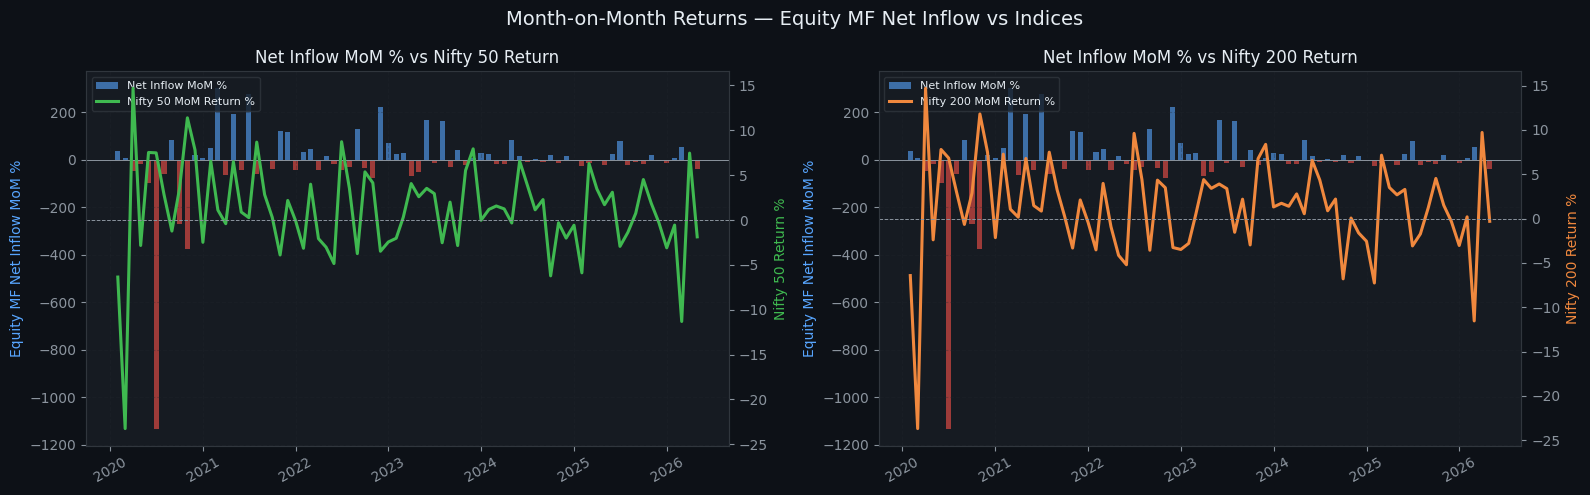

Fig 2 saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle(
    "Month-on-Month Returns — Equity MF Net Inflow vs Indices",
    fontsize=14
)

for ax, ret_col, label, color in [
    (axes[0], "Nifty50_ret",  "Nifty 50",  C_N50),
    (axes[1], "Nifty200_ret", "Nifty 200", C_N200)
]:
    ax2 = ax.twinx()

    # Bar colors for Net Inflow MoM %
    bar_colors = [
        C_AUM if v >= 0 else "#f85149"
        for v in df_clean["AUM_MoM_pct"]
    ]

    # Net Inflow MoM % bars
    ax.bar(
        df_clean["Month"],
        df_clean["AUM_MoM_pct"],
        color=bar_colors,
        alpha=0.60,
        width=20,
        label="Net Inflow MoM %"
    )

    # Index MoM return line
    ax2.plot(
        df_clean["Month"],
        df_clean[ret_col],
        color=color,
        lw=2.2,
        label=f"{label} MoM Return %"
    )

    # Zero lines
    ax.axhline(
        0,
        color="#8b949e",
        lw=0.7
    )

    ax2.axhline(
        0,
        color="#8b949e",
        lw=0.7,
        ls="--"
    )

    # Labels
    ax.set_ylabel(
        "Equity MF Net Inflow MoM %",
        color=C_AUM
    )

    ax2.set_ylabel(
        f"{label} Return %",
        color=color
    )

    ax.set_title(
        f"Net Inflow MoM % vs {label} Return"
    )

    # Legend
    lines1, l1 = ax.get_legend_handles_labels()
    lines2, l2 = ax2.get_legend_handles_labels()

    ax.legend(
        lines1 + lines2,
        l1 + l2,
        loc="upper left",
        fontsize=8
    )

    # Formatting
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "fig_02_mom_comparison.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Fig 2 saved")

In [5]:
from statsmodels.tsa.stattools import adfuller

print("=" * 70)
print("AUGMENTED DICKEY-FULLER UNIT ROOT TESTS")
print("=" * 70)

# ============================================================
# ADF tests
# Note:
# Equity_Net_AUM_Cr is net inflow and can be negative.
# Therefore, log_AUM is not valid.
# We use asinh_AUM instead.
# ============================================================

test_series = {
    "Net_Inflow_Level":     df_clean["Equity_Net_AUM_Cr"],
    "AUM_MoM_pct":          df_clean["AUM_MoM_pct"],
    "AUM_MoM_abs":          df_clean["AUM_MoM_abs"],
    "asinh_AUM":            df_clean["asinh_AUM"],
    "d_asinh_AUM":          df_clean["d_asinh_AUM"],
    "log_N50":              df_clean["log_N50"],
    "dlog_N50":             df_clean["dlog_N50"],
    "log_N200":             df_clean["log_N200"],
    "dlog_N200":            df_clean["dlog_N200"],
}

for name, series in test_series.items():
    s = series.dropna()

    if len(s) < 10:
        print(f"{name:<20}  Not enough observations")
        continue

    result = adfuller(s, autolag="AIC")

    stat = result[0]
    pval = result[1]
    lags = result[2]
    nobs = result[3]

    star = "***" if pval < 0.01 else (
        "**" if pval < 0.05 else (
            "*" if pval < 0.10 else ""
        )
    )

    status = "STATIONARY" if pval < 0.05 else "NON-STATIONARY"

    print(
        f"{name:<20}  "
        f"ADF={stat:8.3f}  "
        f"p={pval:.4f}{star:<3}  "
        f"lags={lags:<2}  "
        f"nobs={nobs:<3}  "
        f"→ {status}"
    )

AUGMENTED DICKEY-FULLER UNIT ROOT TESTS
Net_Inflow_Level      ADF=  -2.374  p=0.1493     lags=0   nobs=75   → NON-STATIONARY
AUM_MoM_pct           ADF=  -5.170  p=0.0000***  lags=12  nobs=63   → STATIONARY
AUM_MoM_abs           ADF=  -7.762  p=0.0000***  lags=1   nobs=74   → STATIONARY
asinh_AUM             ADF=  -2.257  p=0.1863     lags=1   nobs=74   → NON-STATIONARY
d_asinh_AUM           ADF=  -5.823  p=0.0000***  lags=7   nobs=68   → STATIONARY
log_N50               ADF=  -1.578  p=0.4945     lags=0   nobs=75   → NON-STATIONARY
dlog_N50              ADF=  -9.452  p=0.0000***  lags=0   nobs=75   → STATIONARY
log_N200              ADF=  -1.419  p=0.5731     lags=0   nobs=75   → NON-STATIONARY
dlog_N200             ADF=  -9.232  p=0.0000***  lags=0   nobs=75   → STATIONARY


In [6]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np

print("=" * 75)
print("PEARSON & SPEARMAN CORRELATIONS")
print("Equity MF Net Inflow / Net Inflow MoM% vs Index Returns")
print("=" * 75)

pairs = [
    ("Equity_Net_AUM_Cr", "Nifty50_ret",  "Net Inflow Level vs Nifty 50 Return"),
    ("Equity_Net_AUM_Cr", "Nifty200_ret", "Net Inflow Level vs Nifty 200 Return"),
    ("AUM_MoM_pct",      "Nifty50_ret",  "Net Inflow MoM% vs Nifty 50 Return"),
    ("AUM_MoM_pct",      "Nifty200_ret", "Net Inflow MoM% vs Nifty 200 Return"),
]

rows = []

for x_col, y_col, label in pairs:
    temp = df_clean[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

    if len(temp) < 3:
        rows.append({
            "Pair": label,
            "N": len(temp),
            "Pearson r": np.nan,
            "Pearson p": np.nan,
            "Spearman ρ": np.nan,
            "Spearman p": np.nan
        })
        continue

    x = temp[x_col]
    y = temp[y_col]

    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)

    rows.append({
        "Pair": label,
        "N": len(temp),
        "Pearson r": round(r_p, 4),
        "Pearson p": round(p_p, 4),
        "Spearman ρ": round(r_s, 4),
        "Spearman p": round(p_s, 4)
    })

corr_df = pd.DataFrame(rows)

print(corr_df.to_string(index=False))
display(corr_df)

PEARSON & SPEARMAN CORRELATIONS
Equity MF Net Inflow / Net Inflow MoM% vs Index Returns
                                Pair  N  Pearson r  Pearson p  Spearman ρ  Spearman p
 Net Inflow Level vs Nifty 50 Return 76    -0.2662     0.0201     -0.2762      0.0157
Net Inflow Level vs Nifty 200 Return 76    -0.2616     0.0224     -0.2801      0.0143
  Net Inflow MoM% vs Nifty 50 Return 76    -0.2775     0.0152     -0.3862      0.0006
 Net Inflow MoM% vs Nifty 200 Return 76    -0.2505     0.0291     -0.3757      0.0008


,Pair,N,Pearson r,Pearson p,Spearman ρ,Spearman p
0,Net Inflow Level vs Nifty 50 Return,76,-0.2662,0.0201,-0.2762,0.0157
1,Net Inflow Level vs Nifty 200 Return,76,-0.2616,0.0224,-0.2801,0.0143
2,Net Inflow MoM% vs Nifty 50 Return,76,-0.2775,0.0152,-0.3862,0.0006
3,Net Inflow MoM% vs Nifty 200 Return,76,-0.2505,0.0291,-0.3757,0.0008


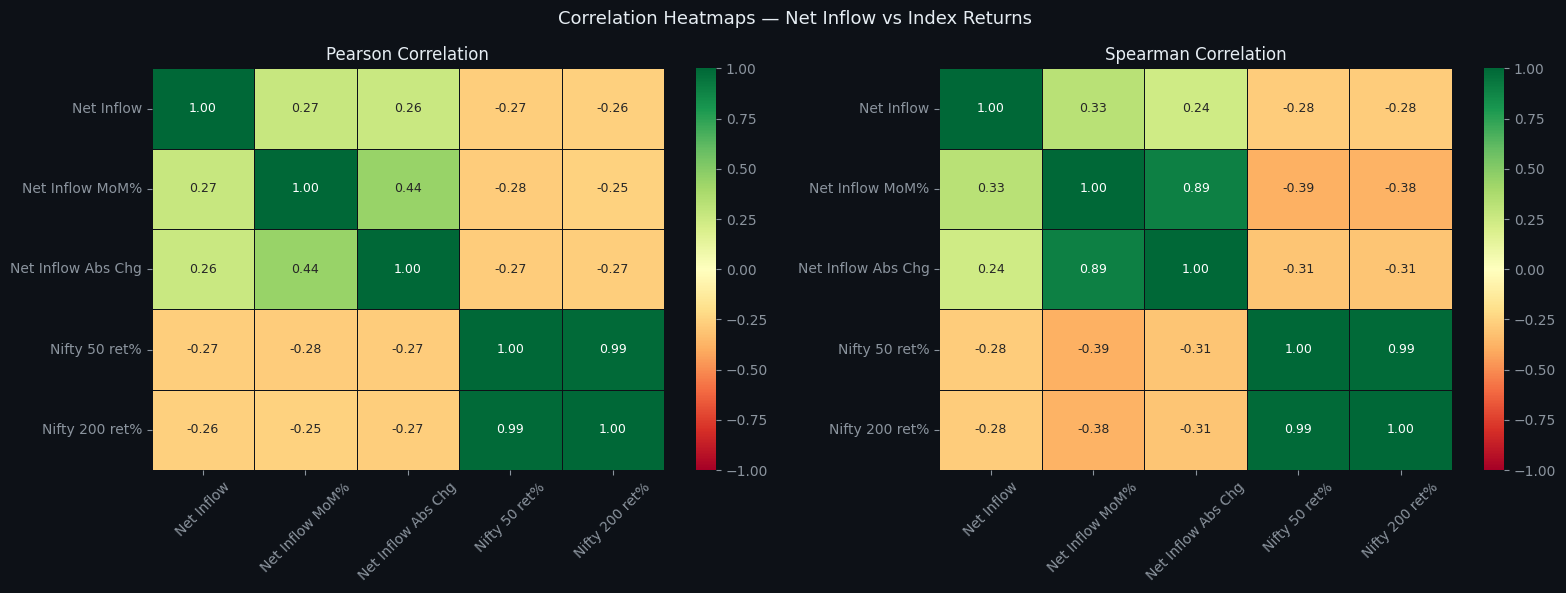

Fig 3 saved


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Figure 3 — Correlation Heatmaps
# Net Inflow / Net Inflow MoM% vs Index Returns
# No dlog, no asinh
# ============================================================

heat_cols = [
    "Equity_Net_AUM_Cr",
    "AUM_MoM_pct",
    "AUM_MoM_abs",
    "Nifty50_ret",
    "Nifty200_ret"
]

heat_labels = [
    "Net Inflow",
    "Net Inflow MoM%",
    "Net Inflow Abs Chg",
    "Nifty 50 ret%",
    "Nifty 200 ret%"
]

# ------------------------------------------------------------
# Correlation matrices
# ------------------------------------------------------------

corr_mat = df_clean[heat_cols].corr(method="pearson")
scorr_mat = df_clean[heat_cols].corr(method="spearman")

# ------------------------------------------------------------
# Plot heatmaps
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Correlation Heatmaps — Net Inflow vs Index Returns",
    fontsize=13
)

kw = dict(
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="#0d1117",
    annot_kws={"size": 9}
)

for ax, mat, title in [
    (axes[0], corr_mat, "Pearson Correlation"),
    (axes[1], scorr_mat, "Spearman Correlation")
]:
    sns.heatmap(
        mat,
        ax=ax,
        xticklabels=heat_labels,
        yticklabels=heat_labels,
        **kw
    )

    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()

plt.savefig(
    "fig_03_heatmap.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Fig 3 saved")

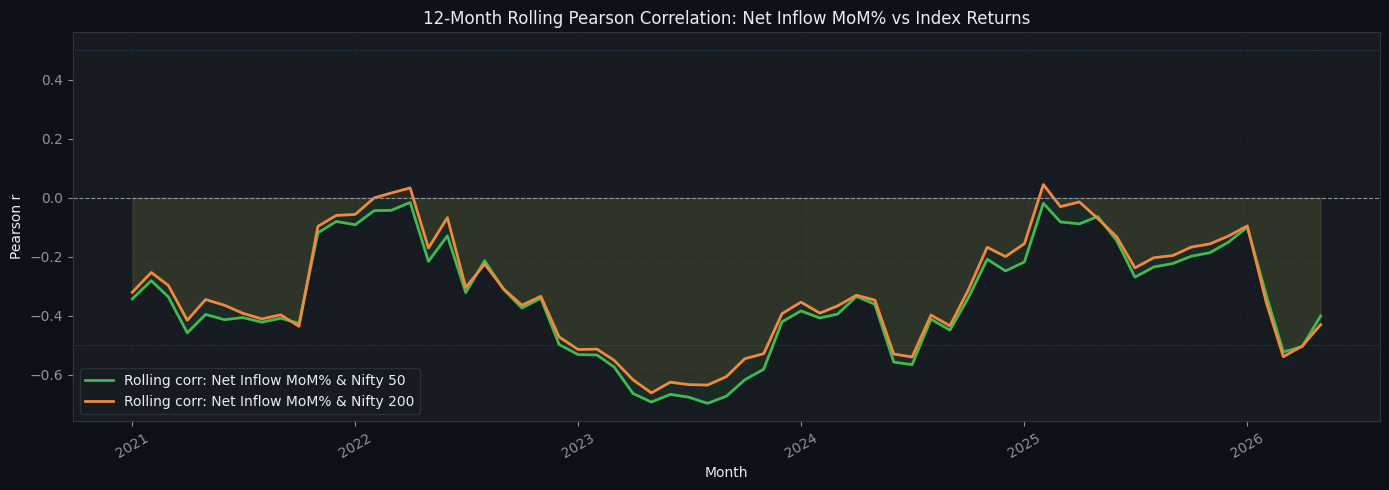

Fig 4 saved


In [8]:
window = 12

# ============================================================
# Figure 4 — Rolling Correlation
# Equity MF Net Inflow MoM% vs Index Returns
# ============================================================

df_clean = df_clean.copy()

df_clean["roll_corr_N50"] = (
    df_clean["AUM_MoM_pct"]
    .rolling(window)
    .corr(df_clean["Nifty50_ret"])
)

df_clean["roll_corr_N200"] = (
    df_clean["AUM_MoM_pct"]
    .rolling(window)
    .corr(df_clean["Nifty200_ret"])
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_clean["Month"],
    df_clean["roll_corr_N50"],
    color=C_N50,
    lw=2,
    label="Rolling corr: Net Inflow MoM% & Nifty 50"
)

ax.plot(
    df_clean["Month"],
    df_clean["roll_corr_N200"],
    color=C_N200,
    lw=2,
    label="Rolling corr: Net Inflow MoM% & Nifty 200"
)

ax.axhline(
    0,
    color="#8b949e",
    lw=0.8,
    ls="--"
)

ax.axhline(
    0.5,
    color="#58a6ff",
    lw=0.5,
    ls=":",
    alpha=0.5
)

ax.axhline(
    -0.5,
    color="#f85149",
    lw=0.5,
    ls=":",
    alpha=0.5
)

ax.fill_between(
    df_clean["Month"],
    df_clean["roll_corr_N50"],
    0,
    alpha=0.10,
    color=C_N50
)

ax.fill_between(
    df_clean["Month"],
    df_clean["roll_corr_N200"],
    0,
    alpha=0.10,
    color=C_N200
)

ax.set_title(
    f"{window}-Month Rolling Pearson Correlation: Net Inflow MoM% vs Index Returns"
)

ax.set_ylabel("Pearson r")
ax.set_xlabel("Month")

ax.legend()
ax.grid(True, alpha=0.4)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

plt.savefig(
    "fig_04_rolling_corr.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Fig 4 saved")

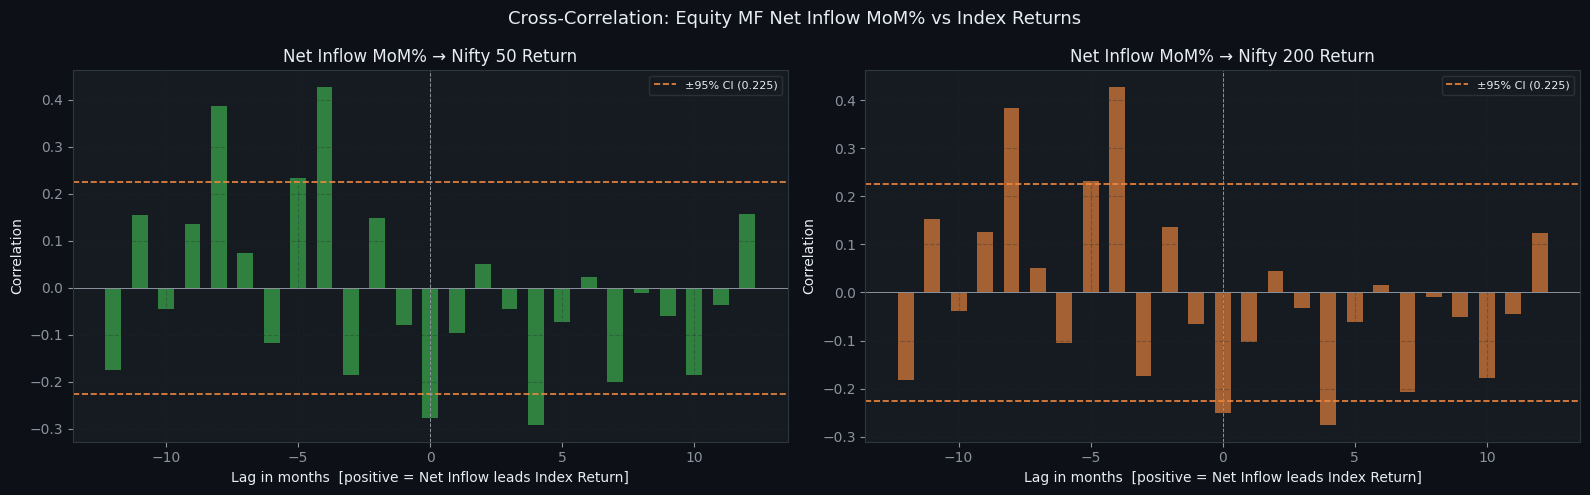

Fig 5 saved
Nifty 50: peak |CCF| = 0.426 at lag -4 months → Nifty 50 leads Net Inflow by 4 months
Nifty 200: peak |CCF| = 0.427 at lag -4 months → Nifty 200 leads Net Inflow by 4 months


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure 5 — Cross-Correlation
# Equity MF Net Inflow MoM% vs Index Returns
# Positive lag = Net Inflow leads index return
# ============================================================

max_lag = 12

# ------------------------------------------------------------
# Manual CCF with both positive and negative lags
# ------------------------------------------------------------

def full_ccf(a, b, max_lag=12):
    """
    Cross-correlation function with positive and negative lags.

    Interpretation:
    - a = Net Inflow MoM%
    - b = Index Return%

    lag > 0  : Net Inflow leads Index Return by lag months
    lag < 0  : Index Return leads Net Inflow by abs(lag) months
    lag = 0  : Same-month correlation
    """

    lags = range(-max_lag, max_lag + 1)
    corrs = []

    for lag in lags:
        if lag < 0:
            # b leads a
            x = a[-lag:]
            y = b[:lag]

        elif lag == 0:
            # same month
            x = a
            y = b

        else:
            # a leads b
            x = a[:-lag]
            y = b[lag:]

        if len(x) < 3 or len(y) < 3:
            corrs.append(np.nan)
        else:
            corrs.append(np.corrcoef(x, y)[0, 1])

    return list(lags), corrs

# ------------------------------------------------------------
# Clean aligned data
# ------------------------------------------------------------

ccf_df = df_clean[
    [
        "Month",
        "AUM_MoM_pct",
        "Nifty50_ret",
        "Nifty200_ret"
    ]
].replace([np.inf, -np.inf], np.nan).dropna().copy()

aum_mom = ccf_df["AUM_MoM_pct"].values
nifty50_ret = ccf_df["Nifty50_ret"].values
nifty200_ret = ccf_df["Nifty200_ret"].values

# ------------------------------------------------------------
# Compute CCF
# Positive lag means AUM / Net Inflow leads index return
# ------------------------------------------------------------

lags_list, ccf_n50 = full_ccf(aum_mom, nifty50_ret, max_lag)
lags_list, ccf_n200 = full_ccf(aum_mom, nifty200_ret, max_lag)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle(
    "Cross-Correlation: Equity MF Net Inflow MoM% vs Index Returns",
    fontsize=13
)

ci = 1.96 / np.sqrt(len(ccf_df))

for ax, ccf_vals, title, color in [
    (
        axes[0],
        ccf_n50,
        "Net Inflow MoM% → Nifty 50 Return",
        C_N50
    ),
    (
        axes[1],
        ccf_n200,
        "Net Inflow MoM% → Nifty 200 Return",
        C_N200
    )
]:
    ax.bar(
        lags_list,
        ccf_vals,
        color=color,
        alpha=0.65,
        width=0.6
    )

    ax.axhline(
        ci,
        color="#f0883e",
        lw=1.2,
        ls="--",
        label=f"±95% CI ({ci:.3f})"
    )

    ax.axhline(
        -ci,
        color="#f0883e",
        lw=1.2,
        ls="--"
    )

    ax.axhline(
        0,
        color="#8b949e",
        lw=0.7
    )

    ax.axvline(
        0,
        color="#8b949e",
        lw=0.7,
        ls="--"
    )

    ax.set_title(title)

    ax.set_xlabel(
        "Lag in months  [positive = Net Inflow leads Index Return]"
    )

    ax.set_ylabel("Correlation")

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "fig_05_ccf.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Fig 5 saved")

# ------------------------------------------------------------
# Print max-correlation lag
# ------------------------------------------------------------

for name, ccf_vals in [
    ("Nifty 50", ccf_n50),
    ("Nifty 200", ccf_n200)
]:
    ccf_arr = np.array(ccf_vals, dtype=float)

    best_idx = np.nanargmax(np.abs(ccf_arr))
    best_lag = lags_list[best_idx]
    best_r = ccf_arr[best_idx]

    if best_lag > 0:
        interpretation = f"Net Inflow leads {name} by {best_lag} months"
    elif best_lag < 0:
        interpretation = f"{name} leads Net Inflow by {abs(best_lag)} months"
    else:
        interpretation = "Same-month relationship"

    print(
        f"{name}: peak |CCF| = {best_r:.3f} "
        f"at lag {best_lag:+d} months → {interpretation}"
    )

In [12]:
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd
import numpy as np

# ============================================================
# GRANGER CAUSALITY TESTS
# Equity MF Net Inflow MoM% vs Index Returns
# ============================================================

print("=" * 80)
print("GRANGER CAUSALITY TESTS")
print("Stationary variables used: AUM_MoM_pct, Nifty50_ret, Nifty200_ret")
print("=" * 80)

max_lag = 12

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def run_granger_test(df, cause_col, effect_col, cause_name, effect_name, max_lag=12):
    """
    Tests whether cause_col Granger-causes effect_col.

    statsmodels requires dataframe order:
    [effect variable, cause variable]
    """

    temp = (
        df[[effect_col, cause_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    print("\n" + "-" * 80)
    print(f"Null Hypothesis: {cause_name} does NOT Granger-cause {effect_name}")
    print("-" * 80)

    result = grangercausalitytests(
        temp[[effect_col, cause_col]],
        maxlag=max_lag,
        verbose=False
    )

    rows = []

    for lag in range(1, max_lag + 1):
        test_result = result[lag][0]

        ssr_f_stat = test_result["ssr_ftest"][0]
        ssr_f_pval = test_result["ssr_ftest"][1]

        chi2_stat = test_result["ssr_chi2test"][0]
        chi2_pval = test_result["ssr_chi2test"][1]

        lr_stat = test_result["lrtest"][0]
        lr_pval = test_result["lrtest"][1]

        params_f_stat = test_result["params_ftest"][0]
        params_f_pval = test_result["params_ftest"][1]

        decision_5pct = "Reject H0" if ssr_f_pval < 0.05 else "Fail to Reject H0"
        decision_10pct = "Reject H0" if ssr_f_pval < 0.10 else "Fail to Reject H0"

        rows.append({
            "Direction": f"{cause_name} → {effect_name}",
            "Lag": lag,
            "SSR F-stat": round(ssr_f_stat, 4),
            "SSR F p-value": round(ssr_f_pval, 4),
            "Chi2 p-value": round(chi2_pval, 4),
            "LR p-value": round(lr_pval, 4),
            "Params F p-value": round(params_f_pval, 4),
            "Decision at 5%": decision_5pct,
            "Decision at 10%": decision_10pct
        })

    out = pd.DataFrame(rows)

    print(out.to_string(index=False))

    best_row = out.loc[out["SSR F p-value"].idxmin()]

    print("\nBest lag based on minimum SSR F-test p-value:")
    print(
        f"Lag {int(best_row['Lag'])}: "
        f"p-value = {best_row['SSR F p-value']:.4f} "
        f"→ {best_row['Decision at 5%']} at 5%"
    )

    return out

# ------------------------------------------------------------
# Prepare clean data
# ------------------------------------------------------------

gc_df = (
    df_clean[
        [
            "Month",
            "AUM_MoM_pct",
            "Nifty50_ret",
            "Nifty200_ret"
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print("Observations used:", len(gc_df))
print("Date range:", gc_df["Month"].min(), "to", gc_df["Month"].max())

# ------------------------------------------------------------
# 1. Net Inflow MoM% → Nifty Returns
# ------------------------------------------------------------

gc_aum_to_n50 = run_granger_test(
    df=gc_df,
    cause_col="AUM_MoM_pct",
    effect_col="Nifty50_ret",
    cause_name="Net Inflow MoM%",
    effect_name="Nifty 50 Return",
    max_lag=max_lag
)

gc_aum_to_n200 = run_granger_test(
    df=gc_df,
    cause_col="AUM_MoM_pct",
    effect_col="Nifty200_ret",
    cause_name="Net Inflow MoM%",
    effect_name="Nifty 200 Return",
    max_lag=max_lag
)

# ------------------------------------------------------------
# 2. Nifty Returns → Net Inflow MoM%
# ------------------------------------------------------------

gc_n50_to_aum = run_granger_test(
    df=gc_df,
    cause_col="Nifty50_ret",
    effect_col="AUM_MoM_pct",
    cause_name="Nifty 50 Return",
    effect_name="Net Inflow MoM%",
    max_lag=max_lag
)

gc_n200_to_aum = run_granger_test(
    df=gc_df,
    cause_col="Nifty200_ret",
    effect_col="AUM_MoM_pct",
    cause_name="Nifty 200 Return",
    effect_name="Net Inflow MoM%",
    max_lag=max_lag
)

# ------------------------------------------------------------
# 3. Combine all results
# ------------------------------------------------------------

granger_summary_df = pd.concat(
    [
        gc_aum_to_n50,
        gc_aum_to_n200,
        gc_n50_to_aum,
        gc_n200_to_aum
    ],
    ignore_index=True
)

print("\n" + "=" * 80)
print("COMBINED GRANGER CAUSALITY SUMMARY")
print("=" * 80)

display(granger_summary_df)

# ------------------------------------------------------------
# 4. Show only significant results
# ------------------------------------------------------------

significant_5pct = granger_summary_df[
    granger_summary_df["SSR F p-value"] < 0.05
].copy()

significant_10pct = granger_summary_df[
    granger_summary_df["SSR F p-value"] < 0.10
].copy()

print("\n" + "=" * 80)
print("SIGNIFICANT RESULTS AT 5%")
print("=" * 80)

if significant_5pct.empty:
    print("No Granger-causality result is significant at 5%.")
else:
    display(significant_5pct)

print("\n" + "=" * 80)
print("SIGNIFICANT RESULTS AT 10%")
print("=" * 80)

if significant_10pct.empty:
    print("No Granger-causality result is significant at 10%.")
else:
    display(significant_10pct)

GRANGER CAUSALITY TESTS
Stationary variables used: AUM_MoM_pct, Nifty50_ret, Nifty200_ret
Observations used: 76
Date range: 2020-02-01 00:00:00 to 2026-05-01 00:00:00

--------------------------------------------------------------------------------
Null Hypothesis: Net Inflow MoM% does NOT Granger-cause Nifty 50 Return
--------------------------------------------------------------------------------
                        Direction  Lag  SSR F-stat  SSR F p-value  Chi2 p-value  LR p-value  Params F p-value    Decision at 5%   Decision at 10%
Net Inflow MoM% → Nifty 50 Return    1      1.2427         0.2687        0.2552      0.2573            0.2687 Fail to Reject H0 Fail to Reject H0
Net Inflow MoM% → Nifty 50 Return    2      1.1096         0.3355        0.3042      0.3100            0.3355 Fail to Reject H0 Fail to Reject H0
Net Inflow MoM% → Nifty 50 Return    3      0.4636         0.7087        0.6735      0.6771            0.7087 Fail to Reject H0 Fail to Reject H0
Net Inflow MoM

,Direction,Lag,SSR F-stat,SSR F p-value,Chi2 p-value,LR p-value,Params F p-value,Decision at 5%,Decision at 10%
0,Net Inflow MoM% → Nifty 50 Return,1,1.2427,0.2687,0.2552,0.2573,0.2687,Fail to Reject H0,Fail to Reject H0
1,Net Inflow MoM% → Nifty 50 Return,2,1.1096,0.3355,0.3042,0.3100,0.3355,Fail to Reject H0,Fail to Reject H0
2,Net Inflow MoM% → Nifty 50 Return,3,0.4636,0.7087,0.6735,0.6771,0.7087,Fail to Reject H0,Fail to Reject H0
3,Net Inflow MoM% → Nifty 50 Return,4,2.4237,0.0573,0.0257,0.0356,0.0573,Fail to Reject H0,Reject H0
4,Net Inflow MoM% → Nifty 50 Return,5,1.8605,0.1148,0.0512,0.0689,0.1148,Fail to Reject H0,Fail to Reject H0
5,Net Inflow MoM% → Nifty 50 Return,6,1.4691,0.2052,0.0939,0.1219,0.2052,Fail to Reject H0,Fail to Reject H0
6,Net Inflow MoM% → Nifty 50 Return,7,1.1862,0.3263,0.1566,0.1961,0.3263,Fail to Reject H0,Fail to Reject H0
7,Net Inflow MoM% → Nifty 50 Return,8,1.0892,0.3858,0.1690,0.2177,0.3858,Fail to Reject H0,Fail to Reject H0
8,Net Inflow MoM% → Nifty 50 Return,9,0.8089,0.6103,0.3375,0.3958,0.6103,Fail to Reject H0,Fail to Reject H0
9,Net Inflow MoM% → Nifty 50 Return,10,0.5286,0.8607,0.6530,0.6939,0.8607,Fail to Reject H0,Fail to Reject H0



SIGNIFICANT RESULTS AT 5%


,Direction,Lag,SSR F-stat,SSR F p-value,Chi2 p-value,LR p-value,Params F p-value,Decision at 5%,Decision at 10%
27,Nifty 50 Return → Net Inflow MoM%,4,8.7573,0.0,0.0,0.0,0.0,Reject H0,Reject H0
28,Nifty 50 Return → Net Inflow MoM%,5,8.2965,0.0,0.0,0.0,0.0,Reject H0,Reject H0
39,Nifty 200 Return → Net Inflow MoM%,4,8.0385,0.0,0.0,0.0,0.0,Reject H0,Reject H0
40,Nifty 200 Return → Net Inflow MoM%,5,7.3577,0.0,0.0,0.0,0.0,Reject H0,Reject H0



SIGNIFICANT RESULTS AT 10%


,Direction,Lag,SSR F-stat,SSR F p-value,Chi2 p-value,LR p-value,Params F p-value,Decision at 5%,Decision at 10%
3,Net Inflow MoM% → Nifty 50 Return,4,2.4237,0.0573,0.0257,0.0356,0.0573,Fail to Reject H0,Reject H0
27,Nifty 50 Return → Net Inflow MoM%,4,8.7573,0.0000,0.0000,0.0000,0.0000,Reject H0,Reject H0
28,Nifty 50 Return → Net Inflow MoM%,5,8.2965,0.0000,0.0000,0.0000,0.0000,Reject H0,Reject H0
29,Nifty 50 Return → Net Inflow MoM%,6,1.9800,0.0836,0.0237,0.0392,0.0836,Fail to Reject H0,Reject H0
33,Nifty 50 Return → Net Inflow MoM%,10,1.8312,0.0822,0.0027,0.0126,0.0822,Fail to Reject H0,Reject H0
39,Nifty 200 Return → Net Inflow MoM%,4,8.0385,0.0000,0.0000,0.0000,0.0000,Reject H0,Reject H0
40,Nifty 200 Return → Net Inflow MoM%,5,7.3577,0.0000,0.0000,0.0000,0.0000,Reject H0,Reject H0


In [15]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import pandas as pd
import numpy as np

# ============================================================
# OLS REGRESSION — Lag 0 to Lag 4
# Dependent variable: Net Inflow MoM%
#
# Model 1:
# AUM_MoM_pct ~ Nifty50_ret_lag0 + lag1 + lag2 + lag3 + lag4
#
# Model 2:
# AUM_MoM_pct ~ Nifty200_ret_lag0 + lag1 + lag2 + lag3 + lag4
#
# HAC/Newey-West standard errors used
# ============================================================

print("=" * 90)
print("OLS REGRESSION — Net Inflow MoM% on Index Returns Lag 0 to Lag 4")
print("=" * 90)

# ------------------------------------------------------------
# 1. Prepare dataframe
# ------------------------------------------------------------

reg_df = df_clean[
    [
        "Month",
        "AUM_MoM_pct",
        "Nifty50_ret",
        "Nifty200_ret"
    ]
].replace([np.inf, -np.inf], np.nan).copy()

# ------------------------------------------------------------
# 2. Create lag variables: lag 0, 1, 2, 3, 4
# ------------------------------------------------------------

for lag in range(0, 5):
    reg_df[f"Nifty50_ret_lag{lag}"] = reg_df["Nifty50_ret"].shift(lag)
    reg_df[f"Nifty200_ret_lag{lag}"] = reg_df["Nifty200_ret"].shift(lag)

# ------------------------------------------------------------
# 3. Helper function
# ------------------------------------------------------------

def run_lag_0_to_4_regression(data, y_col, x_cols, model_name, maxlags=4):
    temp = (
        data[["Month", y_col] + x_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    y = temp[y_col]
    X = sm.add_constant(temp[x_cols])

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    dw = durbin_watson(model.resid)

    print("\n" + "-" * 90)
    print(model_name)
    print("-" * 90)

    print(
        f"N={int(model.nobs)}  "
        f"R²={model.rsquared:.4f}  "
        f"Adj-R²={model.rsquared_adj:.4f}  "
        f"F-stat={float(model.fvalue):.4f}  "
        f"F p-value={float(model.f_pvalue):.4f}  "
        f"DW={dw:.4f}  "
        f"SE=HAC/Newey-West"
    )

    print(model.summary2().tables[1].to_string())

    return model, temp

# ------------------------------------------------------------
# 4. Model 1 — Nifty 50 lag 0 to lag 4
# ------------------------------------------------------------

nifty50_lag_cols = [
    "Nifty50_ret_lag0",
    "Nifty50_ret_lag1",
    "Nifty50_ret_lag2",
    "Nifty50_ret_lag3",
    "Nifty50_ret_lag4"
]

model_n50_lag04, reg_n50_lag04 = run_lag_0_to_4_regression(
    data=reg_df,
    y_col="AUM_MoM_pct",
    x_cols=nifty50_lag_cols,
    model_name="Model 1: Net Inflow MoM% ~ Nifty 50 Return Lag 0 to Lag 4",
    maxlags=4
)

# ------------------------------------------------------------
# 5. Model 2 — Nifty 200 lag 0 to lag 4
# ------------------------------------------------------------

nifty200_lag_cols = [
    "Nifty200_ret_lag0",
    "Nifty200_ret_lag1",
    "Nifty200_ret_lag2",
    "Nifty200_ret_lag3",
    "Nifty200_ret_lag4"
]

model_n200_lag04, reg_n200_lag04 = run_lag_0_to_4_regression(
    data=reg_df,
    y_col="AUM_MoM_pct",
    x_cols=nifty200_lag_cols,
    model_name="Model 2: Net Inflow MoM% ~ Nifty 200 Return Lag 0 to Lag 4",
    maxlags=4
)

# ------------------------------------------------------------
# 6. Compact model summary
# ------------------------------------------------------------

summary_rows = []

for name, model in [
    ("Nifty 50 Lag 0 to 4", model_n50_lag04),
    ("Nifty 200 Lag 0 to 4", model_n200_lag04)
]:
    summary_rows.append({
        "Model": name,
        "N": int(model.nobs),
        "R-squared": round(model.rsquared, 4),
        "Adj R-squared": round(model.rsquared_adj, 4),
        "F-stat": round(float(model.fvalue), 4),
        "F p-value": round(float(model.f_pvalue), 4),
        "Durbin-Watson": round(durbin_watson(model.resid), 4),
        "SE Type": "HAC/Newey-West"
    })

lag04_summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("LAG 0 TO 4 OLS SUMMARY TABLE")
print("=" * 90)

print(lag04_summary_df.to_string(index=False))
display(lag04_summary_df)

# ------------------------------------------------------------
# 7. Coefficient table for both models
# ------------------------------------------------------------

coef_rows = []

for model_name, model in [
    ("Nifty 50 Lag 0 to 4", model_n50_lag04),
    ("Nifty 200 Lag 0 to 4", model_n200_lag04)
]:
    coef_table = model.summary2().tables[1].copy()
    coef_table = coef_table.reset_index().rename(columns={"index": "Variable"})
    coef_table.insert(0, "Model", model_name)
    coef_rows.append(coef_table)

coef_summary_df = pd.concat(coef_rows, ignore_index=True)

print("\n" + "=" * 90)
print("COEFFICIENT SUMMARY TABLE")
print("=" * 90)

display(coef_summary_df)

OLS REGRESSION — Net Inflow MoM% on Index Returns Lag 0 to Lag 4

------------------------------------------------------------------------------------------
Model 1: Net Inflow MoM% ~ Nifty 50 Return Lag 0 to Lag 4
------------------------------------------------------------------------------------------
N=72  R²=0.3318  Adj-R²=0.2812  F-stat=4.1455  F p-value=0.0025  DW=1.8242  SE=HAC/Newey-West
                      Coef.   Std.Err.         z     P>|z|     [0.025     0.975]
const             -0.239394  12.571731 -0.019042  0.984807 -24.879534  24.400746
Nifty50_ret_lag0 -11.829051   5.549391 -2.131594  0.033040 -22.705657  -0.952445
Nifty50_ret_lag1  -4.622076   4.160034 -1.111067  0.266540 -12.775592   3.531441
Nifty50_ret_lag2   5.627076   1.862210  3.021720  0.002513   1.977212   9.276939
Nifty50_ret_lag3  -4.290047   3.900925 -1.099751  0.271441 -11.935720   3.355626
Nifty50_ret_lag4  12.590905   7.000897  1.798470  0.072103  -1.130602  26.312412

--------------------------------

,Model,N,R-squared,Adj R-squared,F-stat,F p-value,Durbin-Watson,SE Type
0,Nifty 50 Lag 0 to 4,72,0.3318,0.2812,4.1455,0.0025,1.8242,HAC/Newey-West
1,Nifty 200 Lag 0 to 4,72,0.3108,0.2586,3.7425,0.0048,1.8047,HAC/Newey-West



COEFFICIENT SUMMARY TABLE


,Model,Variable,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,Nifty 50 Lag 0 to 4,const,-0.239394,12.571731,-0.019042,0.984807,-24.879534,24.400746
1,Nifty 50 Lag 0 to 4,Nifty50_ret_lag0,-11.829051,5.549391,-2.131594,0.033040,-22.705657,-0.952445
2,Nifty 50 Lag 0 to 4,Nifty50_ret_lag1,-4.622076,4.160034,-1.111067,0.266540,-12.775592,3.531441
3,Nifty 50 Lag 0 to 4,Nifty50_ret_lag2,5.627076,1.862210,3.021720,0.002513,1.977212,9.276939
4,Nifty 50 Lag 0 to 4,Nifty50_ret_lag3,-4.290047,3.900925,-1.099751,0.271441,-11.935720,3.355626
5,Nifty 50 Lag 0 to 4,Nifty50_ret_lag4,12.590905,7.000897,1.798470,0.072103,-1.130602,26.312412
6,Nifty 200 Lag 0 to 4,const,-2.024264,13.041876,-0.155213,0.876654,-27.585872,23.537344
7,Nifty 200 Lag 0 to 4,Nifty200_ret_lag0,-10.210676,4.912563,-2.078482,0.037665,-19.839122,-0.582229
8,Nifty 200 Lag 0 to 4,Nifty200_ret_lag1,-3.374012,3.716413,-0.907868,0.363948,-10.658048,3.910024
9,Nifty 200 Lag 0 to 4,Nifty200_ret_lag2,5.036595,1.941289,2.594459,0.009474,1.231739,8.841451


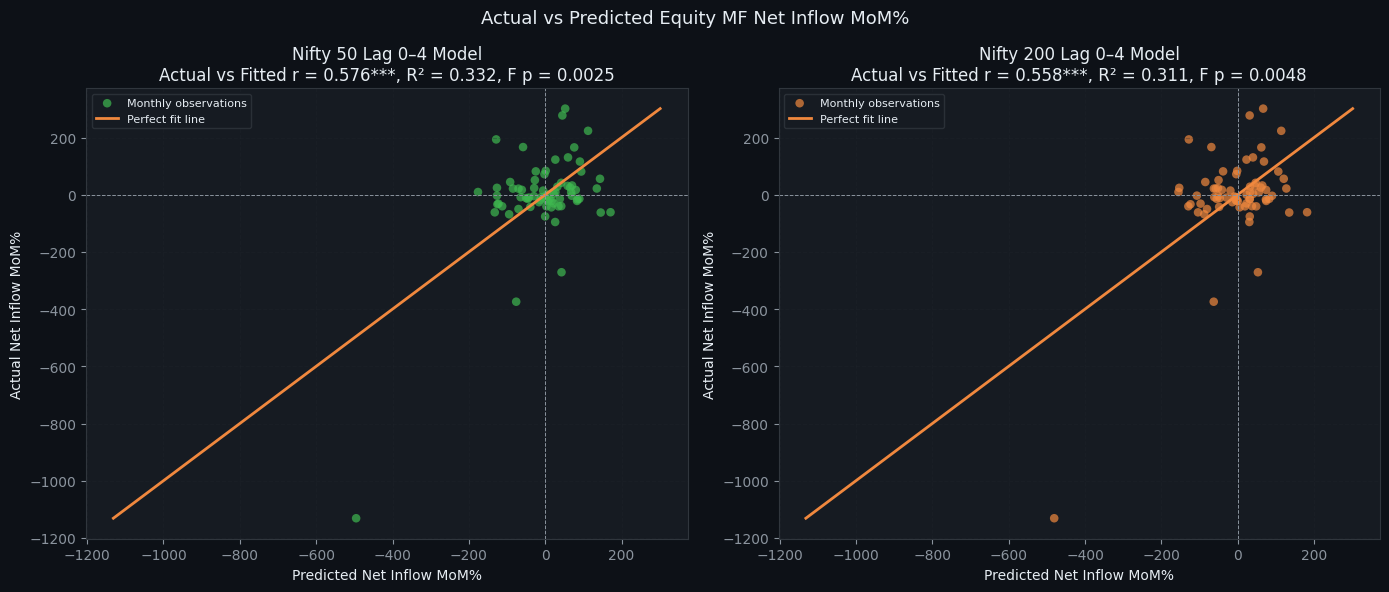

Fig 10 saved


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr

# ============================================================
# Figure 10 — Actual vs Fitted Net Inflow MoM%
# Based on lag 0 to lag 4 regression models
# ============================================================

# ------------------------------------------------------------
# 1. Prepare regression dataframe
# ------------------------------------------------------------

scatter_df = df_clean[
    [
        "Month",
        "AUM_MoM_pct",
        "Nifty50_ret",
        "Nifty200_ret"
    ]
].replace([np.inf, -np.inf], np.nan).copy()

# Create lag 0 to lag 4 variables
for lag in range(0, 5):
    scatter_df[f"Nifty50_ret_lag{lag}"] = scatter_df["Nifty50_ret"].shift(lag)
    scatter_df[f"Nifty200_ret_lag{lag}"] = scatter_df["Nifty200_ret"].shift(lag)

# ------------------------------------------------------------
# 2. Helper function
# ------------------------------------------------------------

def fit_lag_model(data, y_col, x_cols):
    temp = data[["Month", y_col] + x_cols].dropna().copy()

    y = temp[y_col]
    X = sm.add_constant(temp[x_cols])

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 4}
    )

    temp["Fitted_Net_Inflow_MoM_pct"] = model.predict(X)

    return model, temp

# ------------------------------------------------------------
# 3. Fit Nifty 50 and Nifty 200 lag models
# ------------------------------------------------------------

nifty50_lag_cols = [
    "Nifty50_ret_lag0",
    "Nifty50_ret_lag1",
    "Nifty50_ret_lag2",
    "Nifty50_ret_lag3",
    "Nifty50_ret_lag4"
]

nifty200_lag_cols = [
    "Nifty200_ret_lag0",
    "Nifty200_ret_lag1",
    "Nifty200_ret_lag2",
    "Nifty200_ret_lag3",
    "Nifty200_ret_lag4"
]

model_n50_scatter, scatter_n50 = fit_lag_model(
    data=scatter_df,
    y_col="AUM_MoM_pct",
    x_cols=nifty50_lag_cols
)

model_n200_scatter, scatter_n200 = fit_lag_model(
    data=scatter_df,
    y_col="AUM_MoM_pct",
    x_cols=nifty200_lag_cols
)

# ------------------------------------------------------------
# 4. Plot actual vs fitted values
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle(
    "Actual vs Predicted Equity MF Net Inflow MoM%",
    fontsize=13
)

plot_items = [
    (
        axes[0],
        scatter_n50,
        model_n50_scatter,
        "Nifty 50 Lag 0–4 Model",
        C_N50
    ),
    (
        axes[1],
        scatter_n200,
        model_n200_scatter,
        "Nifty 200 Lag 0–4 Model",
        C_N200
    )
]

for ax, temp, model, label, color in plot_items:

    x = temp["Fitted_Net_Inflow_MoM_pct"]
    y = temp["AUM_MoM_pct"]

    r, p = pearsonr(x, y)

    # 45-degree line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())

    ax.scatter(
        x,
        y,
        color=color,
        alpha=0.70,
        s=38,
        edgecolors="none",
        label="Monthly observations"
    )

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="#f0883e",
        lw=2,
        label="Perfect fit line"
    )

    ax.axhline(
        0,
        color="#8b949e",
        lw=0.7,
        ls="--"
    )

    ax.axvline(
        0,
        color="#8b949e",
        lw=0.7,
        ls="--"
    )

    sig = "***" if p < 0.01 else (
        "**" if p < 0.05 else (
            "*" if p < 0.10 else ""
        )
    )

    ax.set_title(
        f"{label}\n"
        f"Actual vs Fitted r = {r:.3f}{sig}, "
        f"R² = {model.rsquared:.3f}, "
        f"F p = {float(model.f_pvalue):.4f}"
    )

    ax.set_xlabel("Predicted Net Inflow MoM%")
    ax.set_ylabel("Actual Net Inflow MoM%")

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "fig_10_scatter.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Fig 10 saved")

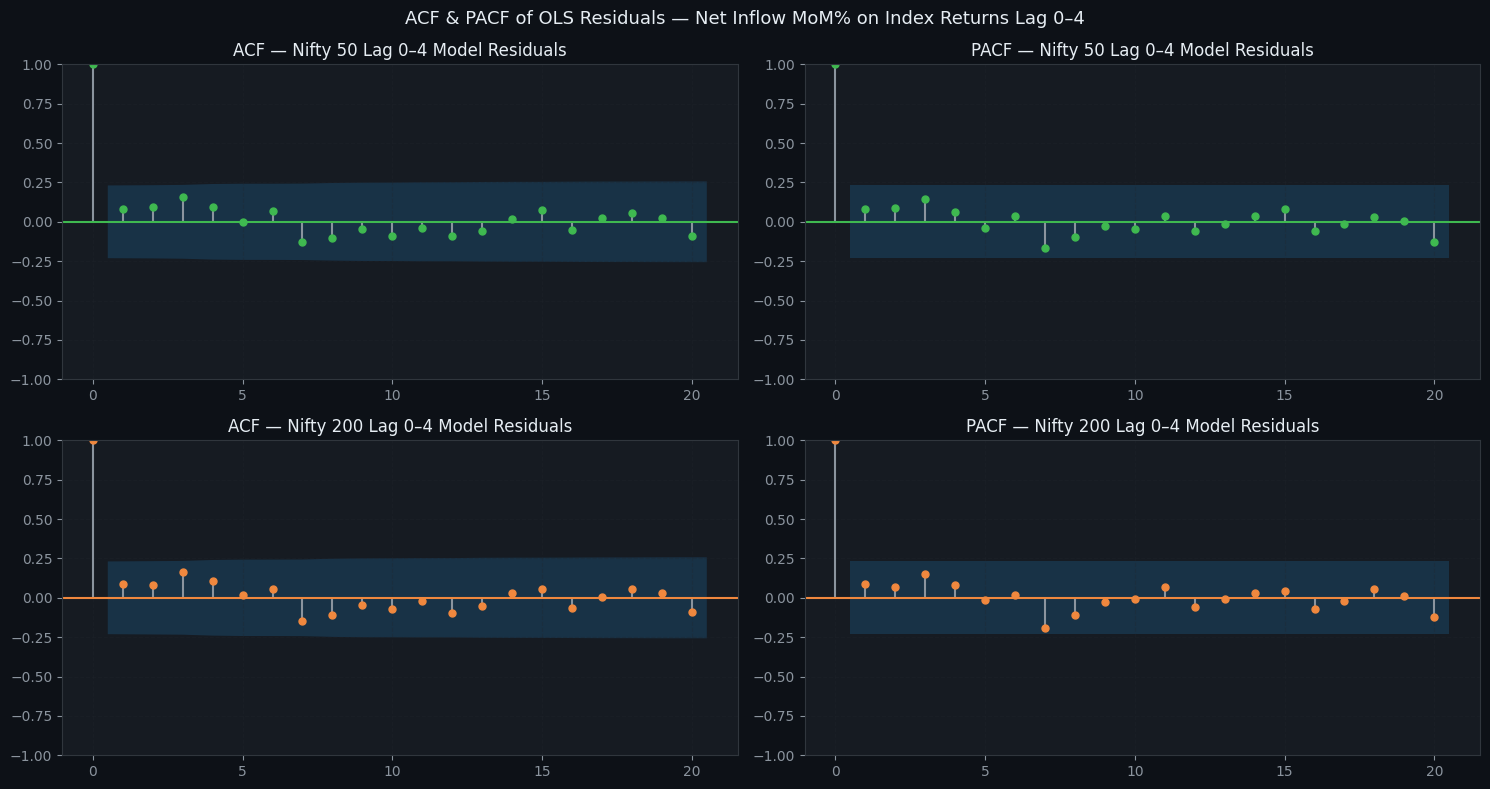

Fig 11 saved


In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Figure 11 — ACF & PACF of Lagged OLS Residuals
# Based on regression:
# Net Inflow MoM% ~ Index Returns Lag 0 to Lag 4
# ============================================================

# ------------------------------------------------------------
# 1. Prepare regression dataframe
# ------------------------------------------------------------

resid_df = df_clean[
    [
        "Month",
        "AUM_MoM_pct",
        "Nifty50_ret",
        "Nifty200_ret"
    ]
].replace([np.inf, -np.inf], np.nan).copy()

# Create lag 0 to lag 4 variables
for lag in range(0, 5):
    resid_df[f"Nifty50_ret_lag{lag}"] = resid_df["Nifty50_ret"].shift(lag)
    resid_df[f"Nifty200_ret_lag{lag}"] = resid_df["Nifty200_ret"].shift(lag)

# ------------------------------------------------------------
# 2. Fit model and return residuals
# ------------------------------------------------------------

def get_lag_model_residuals(data, y_col, x_cols):
    temp = data[["Month", y_col] + x_cols].dropna().copy()

    y = temp[y_col]
    X = sm.add_constant(temp[x_cols])

    model = sm.OLS(y, X).fit()

    temp["Residual"] = model.resid

    return model, temp

nifty50_lag_cols = [
    "Nifty50_ret_lag0",
    "Nifty50_ret_lag1",
    "Nifty50_ret_lag2",
    "Nifty50_ret_lag3",
    "Nifty50_ret_lag4"
]

nifty200_lag_cols = [
    "Nifty200_ret_lag0",
    "Nifty200_ret_lag1",
    "Nifty200_ret_lag2",
    "Nifty200_ret_lag3",
    "Nifty200_ret_lag4"
]

model_n50_resid, resid_n50_df = get_lag_model_residuals(
    data=resid_df,
    y_col="AUM_MoM_pct",
    x_cols=nifty50_lag_cols
)

model_n200_resid, resid_n200_df = get_lag_model_residuals(
    data=resid_df,
    y_col="AUM_MoM_pct",
    x_cols=nifty200_lag_cols
)

# ------------------------------------------------------------
# 3. Plot ACF and PACF
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

fig.suptitle(
    "ACF & PACF of OLS Residuals — Net Inflow MoM% on Index Returns Lag 0–4",
    fontsize=13
)

# Nifty 50 residuals
plot_acf(
    resid_n50_df["Residual"],
    lags=20,
    ax=axes[0, 0],
    alpha=0.05,
    color=C_N50,
    vlines_kwargs={"colors": "#8b949e"}
)

axes[0, 0].set_title("ACF — Nifty 50 Lag 0–4 Model Residuals")

plot_pacf(
    resid_n50_df["Residual"],
    lags=20,
    ax=axes[0, 1],
    alpha=0.05,
    color=C_N50,
    vlines_kwargs={"colors": "#8b949e"},
    method="ywm"
)

axes[0, 1].set_title("PACF — Nifty 50 Lag 0–4 Model Residuals")

# Nifty 200 residuals
plot_acf(
    resid_n200_df["Residual"],
    lags=20,
    ax=axes[1, 0],
    alpha=0.05,
    color=C_N200,
    vlines_kwargs={"colors": "#8b949e"}
)

axes[1, 0].set_title("ACF — Nifty 200 Lag 0–4 Model Residuals")

plot_pacf(
    resid_n200_df["Residual"],
    lags=20,
    ax=axes[1, 1],
    alpha=0.05,
    color=C_N200,
    vlines_kwargs={"colors": "#8b949e"},
    method="ywm"
)

axes[1, 1].set_title("PACF — Nifty 200 Lag 0–4 Model Residuals")

# ------------------------------------------------------------
# 4. Formatting
# ------------------------------------------------------------

for ax in axes.flat:
    ax.set_facecolor("#161b22")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "fig_11_acf_pacf.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Fig 11 saved")